# The Complete Training Loop

We will teach a small neural network to predict a toy sensor reading from a position. A training loop repeatedly makes predictions, measures mistakes, computes gradients, and updates weights. Separate validation examples choose a saved model; test examples evaluate that fixed choice at the end.

This notebook includes all setup and explanations needed to run independently. Use the [README environment](README.md) and restart the kernel before running all cells. Data is generated locally, computation stays on CPU, and no downloads or credentials are needed. The [illustrated notes](09_The_Complete_Training_Loop_Notes.ipynb) describe the same journey.

## Prepare the tools

PyTorch builds and trains the model, NumPy generates the readings, and Matplotlib draws results. `copy` preserves independent weight snapshots. Seeds fix random choices, and a single CPU thread with deterministic operations makes this demonstration repeatable.

## Start with the problem this lesson solves

One successful update is not a trained model. A training loop must repeatedly present examples, calculate mistakes, change parameters, and check whether progress extends to examples that were not used for updates.

The ANN's job in this lesson is to predict a sensor reading from position. Its nonlinear hidden layers can represent a curved relationship. The loop coordinates learning; it does not create representational ability that the chosen architecture lacks.

## Make every operation in one batch concrete

Before the larger nonlinear sensor model, inspect a separate two-example miniature. Use predictor $\hat y=wx+b$, starting $w=0,b=0$, inputs $[1,2]$, and targets $[2,4]$. This one-neuron example uses plain SGD so no optimizer state obscures the arithmetic.

**Forward:** predictions are $[0(1)+0,0(2)+0]=[0,0]$.

**Loss:** errors are $[-2,-4]$; squared errors are $[4,16]$; their mean is $L=(4+16)/2=10$.

**Backward:** for a mean of two squared errors, each prediction's derivative is $2(\hat y_i-y_i)/2$, giving $[-2,-4]$. A weight affects the prediction by multiplying its input, so

$$\frac{\partial L}{\partial w}=(-2)(1)+(-4)(2)=-10.$$

A bias adds one unit to each prediction per unit change, so $\partial L/\partial b=-2-4=-6$.

**Step:** at rate $0.1$, $w'=0-0.1(-10)=1$ and $b'=0-0.1(-6)=0.6$.

**Recompute:** predictions are $[1(1)+0.6,1(2)+0.6]=[1.6,2.6]$. Errors are $[-0.4,-1.4]$, so loss is $(0.16+1.96)/2=1.06$. This batch improved, but the true relation $y=2x$ has not yet been recovered.

**Check a validation example without learning from it:** if a held-out input is $1.5$ with target three, the updated prediction is $1(1.5)+0.6=2.1$ and its squared error is $0.81$. We record this score; we do not backpropagate it. Repeated validation helps choose a checkpoint, so a separate test set is needed for the final evaluation.

**Repeat with the right bookkeeping:** before the next batch, clear old gradients so its update uses its own intended loss. An epoch means one pass through the training data. In the actual companion, 120 training examples divided into batches of 24 give five updates per epoch; 150 epochs give $5\times150=750$ updates. That larger model uses Adam and a nonlinear sensor task, so it is not expected to reproduce this miniature's weights.

## Why each part of the loop has a separate job

Training examples determine gradient updates. Validation examples select settings or saved states. Test examples estimate performance after those choices are fixed. Shuffling changes which examples meet in a batch; it does not change their labels. Saving the best validation state protects against assuming that the final epoch is necessarily best.

`train()` and `eval()` control behavior of layers such as dropout; they do not themselves enable or disable all gradient tracking. A no-gradient context avoids building an unnecessary backward graph during evaluation. The trained model helps by predicting the sensor curve on new positions, which must be checked against a simple baseline.

## Connect the explanation to the code

Read each batch as `zero_grad → model(batch_x) → loss → backward → step`. The optimizer changes parameters only at `step`. The evaluation function measures a fixed network. `copy.deepcopy(model.state_dict())` preserves the chosen values instead of keeping a live reference to numbers that later steps change. Reloading the selected state makes the final test evaluate the model validation actually chose.

The calculations above explain the mechanism before the full experiment. Read the following code cells in order; the printed values and assertions let you compare the implementation with its mathematical meaning.

In [1]:
import copy
import platform
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
plt.rcParams.update({"figure.dpi": 90})
print("Python:", platform.python_version(), "| PyTorch:", torch.__version__)
print("Device: CPU")

Python: 3.9.6 | PyTorch: 2.2.2
Device: CPU


## Make examples and give them separate roles

The clean reading is $0.5\sin(\pi x)+0.3x$: a smooth rise and fall with a small tilt. We add small zero-mean noise to imitate imperfect measurements. `default_rng` is a seeded random generator; `permutation` mixes indices before splitting them into nonoverlapping groups.

Every input and target is a floating-point column, so each row describes one example. The fixed input range needs no fitted scaling. Only training data is plotted at this stage.

Examples: training 120 | validation 40 | test 40


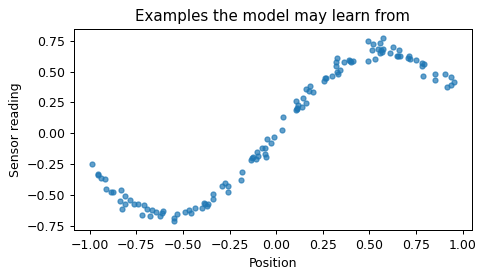

In [2]:
rng = np.random.default_rng(SEED)
def clean_reading(x):
    return 0.5 * np.sin(np.pi * x) + 0.3 * x

positions = rng.uniform(-1., 1., size=(200, 1)).astype(np.float32)
readings = (clean_reading(positions) + rng.normal(0., 0.04, size=(200, 1))).astype(np.float32)
indices = rng.permutation(len(positions))
train_ids, val_ids, test_ids = np.split(indices, [120, 160])
assert not (set(train_ids) & set(val_ids) or set(train_ids) & set(test_ids) or set(val_ids) & set(test_ids))
assert len(set(indices)) == len(positions)
X_train, y_train = torch.from_numpy(positions[train_ids]), torch.from_numpy(readings[train_ids])
X_val, y_val = torch.from_numpy(positions[val_ids]), torch.from_numpy(readings[val_ids])
X_test, y_test = torch.from_numpy(positions[test_ids]), torch.from_numpy(readings[test_ids])
print("Examples: training", len(X_train), "| validation", len(X_val), "| test", len(X_test))
fig, ax = plt.subplots(figsize=(5.5, 3.2))
ax.scatter(X_train[:, 0], y_train[:, 0], s=16, alpha=0.7)
ax.set(xlabel="Position", ylabel="Sensor reading", title="Examples the model may learn from")
plt.tight_layout()
plt.show()

## Build the predictor and the batch loader

`TensorDataset` keeps each position paired with its reading. `DataLoader` serves shuffled batches of twenty-four; its own seeded generator makes their order reproducible. One pass through the loader is an epoch.

The model maps one input through two hidden layers of sixteen values, then to one output. `Linear` applies weighted sums and biases. `Tanh` bends the response smoothly; without nonlinear steps, these layers would collapse into one affine map. The last layer leaves the reading unrestricted.

MSE averages squared prediction errors. Adam updates weights using gradients and running history. We create the optimizer once so that history persists. A copy of the initial model preserves the starting predictions for the final picture.

In [3]:
loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=24,
                          shuffle=True, generator=loader_generator)
model = nn.Sequential(nn.Linear(1, 16), nn.Tanh(), nn.Linear(16, 16), nn.Tanh(), nn.Linear(16, 1))
initial_model = copy.deepcopy(model).eval()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
print(model)
print("Parameters:", sum(p.numel() for p in model.parameters()))
print("Batches per epoch:", len(train_loader))
assert model(X_train[:3]).shape == y_train[:3].shape == (3, 1)

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): Tanh()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): Tanh()
  (4): Linear(in_features=16, out_features=1, bias=True)
)
Parameters: 321
Batches per epoch: 5


## Make one update visible

Use a separate model copy on the first training rows so this demonstration does not alter the full run or consume the loader's shuffle order. Snapshot parameters, clear gradients, predict, measure loss, call `backward`, and finally call `step`.

Backward fills gradient buffers but leaves the parameters unchanged. The optimizer step changes them. We report the same batch's loss again afterward; a decrease here is an observation, not a promise for every update.

In [4]:
demo_model = copy.deepcopy(initial_model).train()
demo_optimizer = torch.optim.Adam(demo_model.parameters(), lr=0.01)
batch_x, batch_y = X_train[:24], y_train[:24]
before = [p.detach().clone() for p in demo_model.parameters()]
demo_optimizer.zero_grad(set_to_none=True)
batch_predictions = demo_model(batch_x)
batch_loss = loss_fn(batch_predictions, batch_y)
batch_loss.backward()
for old, parameter in zip(before, demo_model.parameters()):
    torch.testing.assert_close(old, parameter)
gradient_norm = sum(p.grad.square().sum().item() for p in demo_model.parameters()) ** 0.5
demo_optimizer.step()
with torch.no_grad():
    after_loss = loss_fn(demo_model(batch_x), batch_y).item()
    movement = sum((p - old).square().sum().item() for old, p in zip(before, demo_model.parameters())) ** 0.5
print(f"Same-batch loss: {batch_loss.item():.6f} -> {after_loss:.6f}")
print(f"Gradient size: {gradient_norm:.6f} | parameter movement: {movement:.6f}")
assert movement > 0 and np.isfinite(after_loss)

Same-batch loss: 0.234744 -> 0.161925
Gradient size: 0.711261 | parameter movement: 0.179164


## Give evaluation its own small function

`eval()` selects evaluation behavior; `no_grad()` prevents gradient recording. They do different jobs. Our dense/tanh layers behave identically in training and evaluation modes, but these explicit boundaries make the loop clear.

The function measures MSE on a complete group using one fixed model state. It performs no updates. We use it for training and validation curves; test data will be passed only after checkpoint selection is finished.

In [5]:
def evaluate_mse(network, inputs, targets):
    network.eval()
    with torch.no_grad():
        predictions = network(inputs)
        assert predictions.shape == targets.shape
        return loss_fn(predictions, targets).item()

initial_train_loss = evaluate_mse(model, X_train, y_train)
initial_val_loss = evaluate_mse(model, X_val, y_val)
print(f"Initial training MSE: {initial_train_loss:.6f}")
print(f"Initial validation MSE: {initial_val_loss:.6f}")

Initial training MSE: 0.241735
Initial validation MSE: 0.272784


## Repeat the full cycle and keep the best snapshot

Each epoch visits the entire training loader. Each batch gets a fresh gradient and one update. We then measure full-group losses and copy the weights whenever validation loss improves. A deep copy keeps that checkpoint independent of later updates.

The run uses a fixed budget of a hundred and fifty epochs. The history includes the initial state at epoch zero, which is also eligible for selection. No test examples enter this loop. An update counter makes the distinction between batches and epochs visible.

In [6]:
EPOCHS = 150
history = {"train": [initial_train_loss], "validation": [initial_val_loss]}
best_val_loss = initial_val_loss
best_epoch = 0
best_state = copy.deepcopy(model.state_dict())
update_count = 0
for epoch in range(1, EPOCHS + 1):
    model.train()
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad(set_to_none=True)
        predictions = model(batch_x)
        assert predictions.shape == batch_y.shape
        loss = loss_fn(predictions, batch_y)
        loss.backward()
        optimizer.step()
        update_count += 1
    train_loss = evaluate_mse(model, X_train, y_train)
    val_loss = evaluate_mse(model, X_val, y_val)
    history["train"].append(train_loss)
    history["validation"].append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
    if epoch in [1, 50, 100, EPOCHS]:
        print(f"Epoch {epoch:3d} | train MSE {train_loss:.6f} | validation MSE {val_loss:.6f}")
assert update_count == EPOCHS * len(train_loader)
assert np.isfinite(history["train"]).all() and np.isfinite(history["validation"]).all()
model.load_state_dict(best_state)
model.eval()
assert np.isclose(evaluate_mse(model, X_val, y_val), best_val_loss)
print(f"Updates: {update_count}; selected epoch: {best_epoch}; validation MSE: {best_val_loss:.6f}")

Epoch   1 | train MSE 0.040366 | validation MSE 0.046755


Epoch  50 | train MSE 0.004691 | validation MSE 0.005627


Epoch 100 | train MSE 0.002243 | validation MSE 0.002768


Epoch 150 | train MSE 0.002144 | validation MSE 0.002917
Updates: 750; selected epoch: 123; validation MSE: 0.001896


## Read the learning curves

Both curves measure fixed model states after epochs, not a mixture of batch losses collected during updates. The vertical line marks the selected validation checkpoint. Some fluctuations are normal with shuffled batches; the best saved state need not be the last state.

The logarithmic vertical scale makes small losses visible. Equal vertical distances represent multiplication by the same factor. These curves describe this run, not a guarantee that a longer run or larger model will improve it.

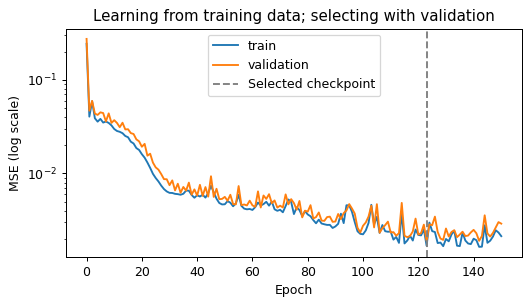

In [7]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for name, values in history.items():
    ax.semilogy(range(len(values)), values, label=name)
ax.axvline(best_epoch, color="gray", linestyle="--", label="Selected checkpoint")
ax.set(xlabel="Epoch", ylabel="MSE (log scale)", title="Learning from training data; selecting with validation")
ax.legend()
plt.tight_layout()
plt.show()

## Evaluate the fixed choice on unseen examples

The checkpoint is selected, so we can now open the test set. Compare it with a simple model that always predicts the average training reading. That baseline uses no test labels for fitting.

MSE averages squared errors; MAE averages absolute errors in the reading's original units. We also report the untrained model to make the before-and-after comparison explicit. These results do not trigger further tuning in this notebook.

In [8]:
with torch.no_grad():
    baseline_prediction = torch.full_like(y_test, y_train.mean().item())
    initial_prediction = initial_model(X_test)
    final_prediction = model(X_test)
    test_results = {}
    for name, guesses in [("Training-mean baseline", baseline_prediction),
                          ("Before training", initial_prediction),
                          ("Selected neural network", final_prediction)]:
        mse = (guesses - y_test).square().mean().item()
        mae = (guesses - y_test).abs().mean().item()
        test_results[name] = {"MSE": mse, "MAE": mae}
        print(f"{name:24s} | test MSE {mse:.6f} | test MAE {mae:.6f}")
assert all(np.isfinite(list(metrics.values())).all() for metrics in test_results.values())

Training-mean baseline   | test MSE 0.285793 | test MAE 0.503849
Before training          | test MSE 0.266897 | test MAE 0.485740
Selected neural network  | test MSE 0.001581 | test MAE 0.030354


## See the same model before and after learning

Dots are held-out test readings. The dashed curve is the known noise-free generator, shown only as an explanatory reference. Colored lines are model predictions on a fixed grid spanning the sampled input range. The grid is not used to fit or select the model.

The final curve should explain the test scores visually: learning is useful here when the network captures the curved pattern rather than merely outputting a constant. Behavior outside this range has not been evaluated.

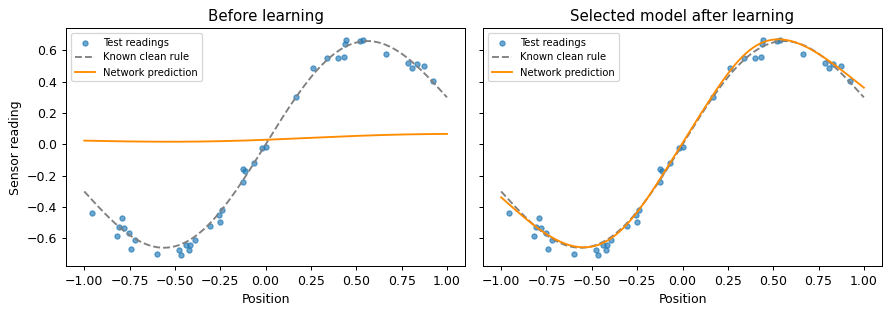

In [9]:
grid = torch.linspace(-1., 1., 200).reshape(-1, 1)
with torch.no_grad():
    before_curve = initial_model(grid).numpy().ravel()
    after_curve = model(grid).numpy().ravel()
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)
for ax, curve, title in zip(axes, [before_curve, after_curve], ["Before learning", "Selected model after learning"]):
    ax.scatter(X_test[:, 0], y_test[:, 0], s=17, alpha=0.65, label="Test readings")
    ax.plot(grid[:, 0], clean_reading(grid.numpy()).ravel(), "--", color="gray", label="Known clean rule")
    ax.plot(grid[:, 0], curve, color="darkorange", label="Network prediction")
    ax.set(xlabel="Position", title=title)
    ax.legend(fontsize=8)
axes[0].set_ylabel("Sensor reading")
plt.tight_layout()
plt.show()

## What this run establishes

The loop connected batches, predictions, loss, gradients, and updates. Validation selected a copied weight state, and the test comparison evaluated that fixed choice against a simple baseline. The known curve and before-and-after picture explain what changed.

The task is deliberately small and synthetic. Lower errors here do not establish performance on real sensors, other distributions, or inputs outside the observed range. Test results are the end of this demonstration, not another signal for choosing its settings.

In [ ]:
import copy
import torch.nn.functional as F

# Patience is measured in validation checks, not optimizer updates.
validation_curve = [0.80, 0.62, 0.51, 0.50, 0.505, 0.504, 0.503]
best_value, best_epoch, wait, patience = float('inf'), -1, 0, 2
for epoch, value in enumerate(validation_curve):
    if value < best_value - 1e-3:
        best_value, best_epoch, wait = value, epoch, 0
    else:
        wait += 1
    if wait >= patience:
        stop_epoch = epoch
        break
assert (best_epoch, stop_epoch) == (3, 5)
print('best epoch:', best_epoch, '| stop after epoch:', stop_epoch)

# L1 makes the objective prefer sparse parameters; dropout is stochastic only in train mode.
weights = torch.tensor([2., -0.1, 0., 0.4])
l1_penalty = weights.abs().sum()
assert l1_penalty.item() == 2.5
probe = nn.Dropout(p=0.5)
probe.train(); torch.manual_seed(9); train_values = probe(torch.ones(2000))
probe.eval(); eval_values = probe(torch.ones(2000))
assert abs(train_values.mean().item() - 1.) < .08
assert torch.allclose(eval_values, torch.ones_like(eval_values))
print('L1 penalty:', l1_penalty.item(), '| dropout train mean:', train_values.mean().item())